In [6]:
import torch
import time
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [ ]:
dataset = load_dataset("imdb").shuffle(seed=42).select_columns(["text", "label"])
# tutaj wybieramy ile chcemy danych załadować
train_data = dataset["train"].select(range(1000))
test_data = dataset["test"].select(range(500))

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

tokenized_train = train_data.map(tokenize_function, batched=True)
tokenized_test = test_data.map(tokenize_function, batched=True)

Map: 100%|██████████| 500/500 [00:00<00:00, 4024.96 examples/s]


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Definicja metryk
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {**acc, **f1}

# Ustawienia treningu - wybraliśmy 3 epoki
training_args = TrainingArguments(
    output_dir="./results_1",
    eval_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_steps=5,
    report_to="none" # nie chcemy wysyłać logów do chmury
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("--- START TRENINGU ---")
start_time = time.time()
trainer.train()
end_time = time.time()
print(f"--- KONIEC: Czas uczenia: {end_time - start_time:.2f} s ---")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7939.25it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


--- START TRENINGU ---


c:\Users\mkuzm\Desktop\Transformers\.transformers\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.483645,0.486847,0.784000,0.783844
2,0.208514,0.649973,0.748000,0.743557
3,0.023060,0.796393,0.790000,0.790013


c:\Users\mkuzm\Desktop\Transformers\.transformers\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\mkuzm\Desktop\Transformers\.transformers\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.23it/s]
c:\Users\mkuzm\Desktop\Transformers\.transformers\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


--- KONIEC: Czas uczenia: 301.46 s ---


Generowanie macierzy pomyłek...


c:\Users\mkuzm\Desktop\Transformers\.transformers\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


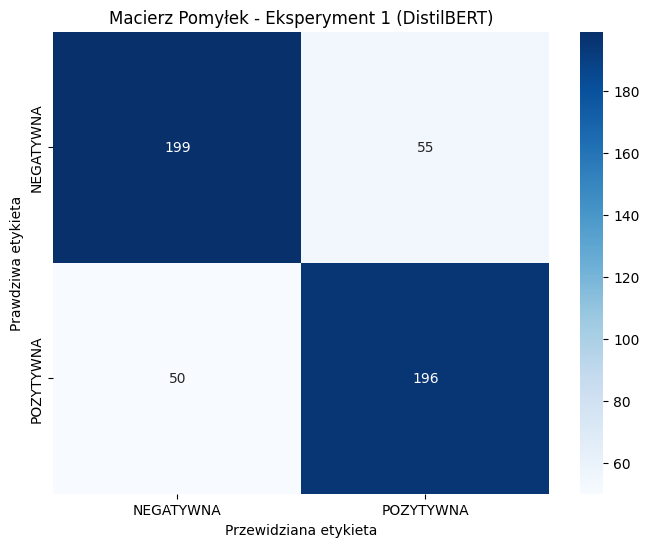

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# 1. Pobieramy przewidywania dla całego zbioru testowego
print("Generowanie macierzy pomyłek...")
predictions_output = trainer.predict(tokenized_test)
preds = np.argmax(predictions_output.predictions, axis=-1)
actuals = predictions_output.label_ids

# 2. Obliczamy macierz za pomocą sklearn
cm = confusion_matrix(actuals, preds)

# 3. Wizualizacja (Professional Plot)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NEGATYWNA', 'POZYTYWNA'], 
            yticklabels=['NEGATYWNA', 'POZYTYWNA'])
plt.xlabel('Przewidziana etykieta')
plt.ylabel('Prawdziwa etykieta')
plt.title('Macierz Pomyłek - Eksperyment 1 (DistilBERT)')
plt.show()

In [29]:
import time
import torch
import torch.nn.functional as F

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to(model.device)
    
    model.eval()
    start_time = time.time()
    with torch.no_grad():
        outputs = model(**inputs)
    end_time = time.time()
    
    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)
    
    confidence, predicted_class_id = torch.max(probs, dim=-1)
    latency = end_time - start_time
    
    labels = {0: "NEGATYWNA", 1: "POZYTYWNA"}
    result_label = labels[predicted_class_id.item()]
    conf_score = confidence.item() * 100
    
    return result_label, conf_score, latency

test_text = "This movie was a masterpiece, the acting was incredible!"
label, score, lat = predict_sentiment(test_text)

print("-" * 30)
print(f"TEKST: {test_text}")
print("-" * 30)
print(f"WERDYKT: {label}")
print(f"PEWNOŚĆ: {score:.2f}%")
print(f"OPÓŹNIENIE (Latency): {lat:.4f} s")
print("-" * 30)

------------------------------
TEKST: This movie was a masterpiece, the acting was incredible!
------------------------------
WERDYKT: POZYTYWNA
PEWNOŚĆ: 99.25%
OPÓŹNIENIE (Latency): 0.0210 s
------------------------------
